<a href="https://colab.research.google.com/github/herredoble/TFM-reconstruccion-3D/blob/raquel%2Fe3/colab_generar_roturas_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E3 — Generación de roturas sintéticas v2

Genera pares `(roto, completo)` mejorados con tres modos de fractura:
- **Plano** (40 %): corte por semiplano con rugosidad — rotura grande
- **Chip** (40 %): eliminación esférica alrededor de un punto de impacto — mella/golpe
- **Cuña** (20 %): intersección de dos planos — trozo de borde que se desprende

**Flujo recomendado:**
1. Celdas 1–5: preparar entorno y datos
2. **Celda 6: preview en 50 modelos** — genera y visualiza para verificar calidad
3. Si el resultado parece correcto → Celda 7: generación completa (~2.367 modelos)
4. Celda 8–9: verificar y guardar en Drive

---
**Entorno:** CPU es suficiente (no necesita GPU)
⏱️ Preview: ~1 min · Generación completa: ~30–40 min

In [ ]:
# ── CELDA 1: Montar Drive ──────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── CELDA 2: Clonar repo e instalar dependencias ───────────────
import os
from getpass import getpass

REPO_DIR = '/content/TFM'

if not os.path.exists(REPO_DIR):
    token = getpass('Pega tu token de GitHub (ghp_...) y pulsa Enter: ')
    repo_url = f'https://{token}@github.com/herredoble/TFM-reconstruccion-3D'
    os.system(f'git clone {repo_url} {REPO_DIR}')
    del token
else:
    os.system(f'git -C {REPO_DIR} pull')

os.chdir(REPO_DIR)
os.system('git checkout raquel/e3')
print('Directorio de trabajo:', os.getcwd())

import subprocess
subprocess.run(['pip', 'install', 'trimesh', 'numpy', 'matplotlib', '--quiet'])
print('Dependencias instaladas.')

Directorio de trabajo: /content/TFM
Dependencias instaladas.


In [ ]:
# ── CELDA 3: RUTAS DE DRIVE ────────────────────────────────────
# Rutas verificadas contra capturas del Drive (14 ago 2026).

DRIVE = '/content/drive/MyDrive'

# Datos de entrada (los .ply limpios de ShapeNet y Objaverse)
RUTA_SHAPENET  = f'{DRIVE}/Datos_E2_E3/General/Shapenet_limpias'   # S mayúscula
RUTA_OBJAVERSE = f'{DRIVE}/Datos_E2_E3/General/Objaverse_limpias'  # O mayúscula

# Dónde guardar las roturas v2 generadas (nueva carpeta, no sobreescribe sintetico_roturas/)
RUTA_SALIDA = f'{DRIVE}/Datos_E2_E3/General/sintetico_roturas_v2'

print('Rutas configuradas:')
print(f'  shapenet limpias : {RUTA_SHAPENET}')
print(f'  objaverse limpias: {RUTA_OBJAVERSE}')
print(f'  salida roturas v2: {RUTA_SALIDA}')

Rutas configuradas:
  shapenet limpias : /content/drive/MyDrive/Datos_E2_E3/General/Shapenet_limpias
  objaverse limpias: /content/drive/MyDrive/Datos_E2_E3/General/Objaverse_limpias
  salida roturas v2: /content/drive/MyDrive/Datos_E2_E3/General/sintetico_roturas_v2


In [ ]:
# ── CELDA 4: Verificar rutas de entrada ───────────────────────
from pathlib import Path

rutas = {
    'shapenet_limpias' : RUTA_SHAPENET,
    'objaverse_limpias': RUTA_OBJAVERSE,
}

ok = True
for nombre, ruta in rutas.items():
    p = Path(ruta)
    if p.exists():
        n = len(list(p.rglob('*.ply')))
        print(f'  ✅ {nombre}: {ruta}  ({n} .ply)')
    else:
        print(f'  ❌ {nombre}: {ruta}  ← NO ENCONTRADO')
        ok = False

if ok:
    print('\nTodo encontrado. Puedes continuar.')
else:
    print('\n⚠️  Alguna ruta no existe. Ajusta las rutas en la Celda 3.')

  ✅ shapenet_limpias: /content/drive/MyDrive/Datos_E2_E3/General/Shapenet_limpias  (2170 .ply)
  ✅ objaverse_limpias: /content/drive/MyDrive/Datos_E2_E3/General/Objaverse_limpias  (197 .ply)

Todo encontrado. Puedes continuar.


In [ ]:
# ── CELDA 5: Copiar .ply desde Drive a local ───────────────────
# El script lee desde Datos/shapenet/limpias y Datos/objaverse/limpias (local).
# Solo copiamos .ply para no llenar el disco de Colab (~400 MB total).

import subprocess
from pathlib import Path

def copiar_ply(src, dst):
    src, dst = Path(src), Path(dst)
    if not src.exists():
        print(f'  [ERROR] no encontrado: {src}'); return 0
    dst.mkdir(parents=True, exist_ok=True)
    n_ya = len(list(dst.rglob('*.ply')))
    if n_ya > 0:
        print(f'  [OK] ya existe: {dst.name}  ({n_ya} .ply)'); return n_ya
    print(f'  Copiando {src.name}...', flush=True)
    r = subprocess.run(
        ['rsync', '-a', '--include=*.ply', '--include=*/', '--exclude=*',
         f'{src}/', str(dst)], capture_output=True, text=True
    )
    if r.returncode != 0:
        print(f'  [ERROR rsync] {r.stderr[:300]}'); return 0
    n = len(list(dst.rglob('*.ply')))
    print(f'  listo — {n} .ply copiados.')
    return n

copiar_ply(RUTA_SHAPENET,  'Datos/shapenet/limpias')
copiar_ply(RUTA_OBJAVERSE, 'Datos/objaverse/limpias')

  [OK] ya existe: limpias  (2170 .ply)
  [OK] ya existe: limpias  (197 .ply)


197

---
## Paso intermedio: PREVIEW de calidad
Genera 50 muestras reales (25 ShapeNet + 25 Objaverse) en una carpeta temporal y las visualiza.
**Lee el grid antes de lanzar la generación completa.**

Qué buscar en el grid:
- **Azul = completo** — debe verse la silueta entera de la vasija (vista lateral + superior)
- **Naranja = roto** — debe faltar una zona, no debe ser un punto aislado ni nube caótica
- Los huecos deben parecer roturas reales: cortes, mellas, esquirlas de borde

In [ ]:
# ── CELDA 6a: Generar 50 muestras de preview ──────────────────
# Usa --max_por_dataset 25 para tomar 25 de ShapeNet y 25 de Objaverse.
# Guarda en roturas_v2_preview/ para no mezclar con la generación final.

from pathlib import Path

PREVIEW_DIR = 'Datos/sintetico/roturas_v2_preview'
Path(PREVIEW_DIR).mkdir(parents=True, exist_ok=True)

print('Generando 50 muestras de preview...', flush=True)

!python Scripts/generar_roturas_sinteticas.py \
    --max_por_dataset 25 \
    --destino {PREVIEW_DIR}

archivos = list(Path(PREVIEW_DIR).glob('*.npy'))
print(f'\nPreview listo: {len(archivos)} archivos en {PREVIEW_DIR}')

Generando 50 muestras de preview...

=== Generación de roturas sintéticas (v2) ===
  Datasets        : ['shapenet', 'objaverse']
  Puntos/nube     : 2048
  Fracción rotura : 15% – 50% eliminado
  Rugosidad corte : 0.05
  Modos (p)       : plano=0.40  chip=0.40  cuña=0.20
  Umbral PCA      : 0.01
  Max por dataset : 25
  Semilla         : 42
  Destino         : Datos/sintetico/roturas_v2_preview
  Dry-run         : False

--- Dataset: shapenet (25 modelos en /content/TFM/Datos/shapenet/limpias) ---
  [FILT] 10839d0dc35c94fcf4fb4dee5181bee                forma plana o lineal (PCA min/max=0.0000 < 0.01)
  [FILT] 11d2b7d8c377632bd4d8765e3910f617               forma plana o lineal (PCA min/max=0.0013 < 0.01)
  [FILT] 126ae26edcd76f27ad5067eac75a07f7               forma plana o lineal (PCA min/max=0.0000 < 0.01)
  [OK]  [chip ] 12c4048e0d2f26a763b2acb037dfbcde       raw:    808  roto:  640 pts (21% eliminado)
  [FILT] 1532546ac3d8a2cff155d75bbf62b80                forma plana o lineal (PCA m

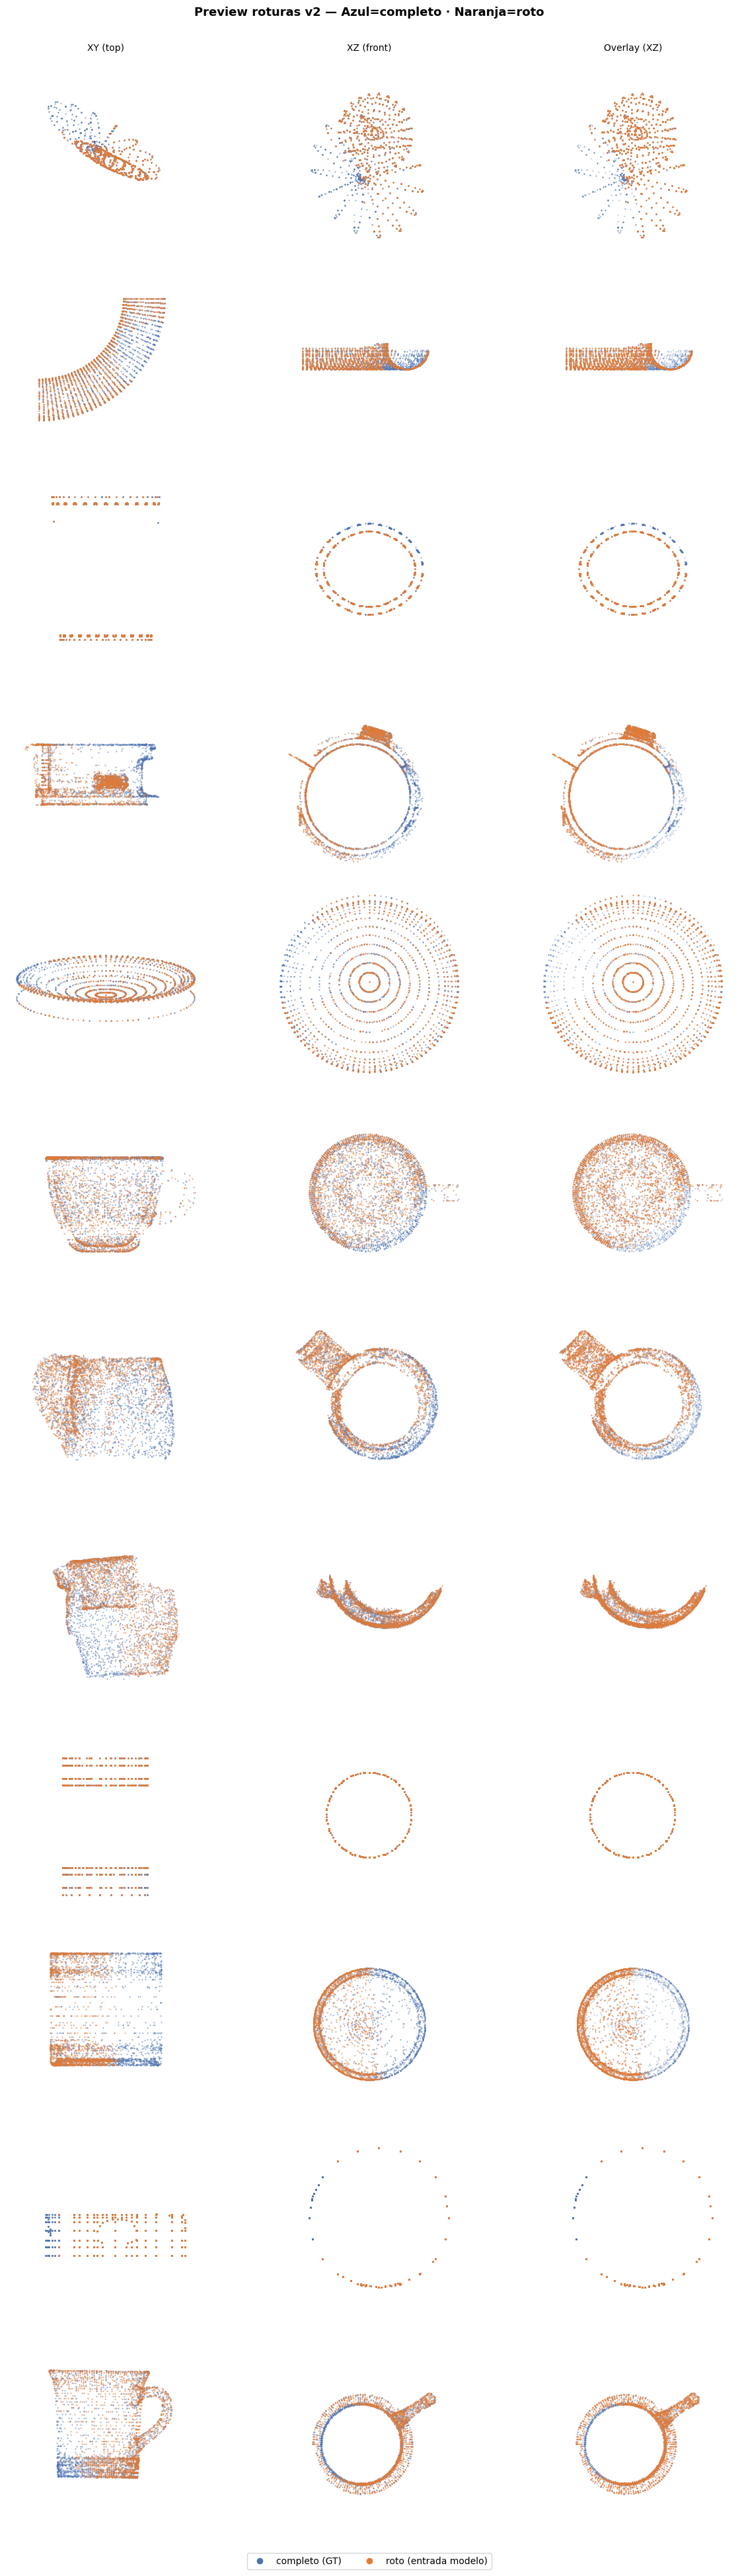


Grid guardado en E3/preview_roturas_v2.png

=== VERIFICA ANTES DE CONTINUAR ===
✅ Buena calidad si: las formas tienen silueta de vasija, los huecos son claros y localizados.
❌ Mala calidad si: nubes dispersas, formas irreconocibles, huecos que cubren casi todo.

Si el resultado te parece correcto → ejecuta la Celda 7 (generación completa).


In [ ]:
# ── CELDA 6b: Visualizar calidad del preview ───────────────────
# Muestra un grid con 12 ejemplos aleatorios.
# Cada fila = un par. Columnas: vista XY (top) · vista XZ (front) · overlay.
#
#   Azul   = nube completa (ground truth)
#   Naranja = nube rota (entrada al modelo)
#
# Un par de calidad:
#   - La completa tiene forma reconocible de vasija
#   - La rota tiene un hueco claro pero conserva la mayor parte
#   - No hay nubes dispersas ni formas irreconocibles

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

PREVIEW_DIR = 'Datos/sintetico/roturas_v2_preview'

completos = sorted(Path(PREVIEW_DIR).glob('*_completo.npy'))
if not completos:
    print('⚠️  No hay archivos en el preview. Ejecuta primero la Celda 6a.')
else:
    N_MOSTRAR = min(12, len(completos))
    muestra = random.sample(completos, N_MOSTRAR)

    fig, axes = plt.subplots(N_MOSTRAR, 3, figsize=(13, N_MOSTRAR * 3.2))
    fig.suptitle(
        'Preview roturas v2 — Azul=completo · Naranja=roto',
        fontsize=13, fontweight='bold', y=1.002
    )

    VISTAS = [
        ('XY (top)',   0, 1),
        ('XZ (front)', 0, 2),
    ]

    for fila, ruta_c in enumerate(muestra):
        ruta_r = Path(str(ruta_c).replace('_completo.npy', '_roto.npy'))
        if not ruta_r.exists():
            continue

        c = np.load(ruta_c)   # (2048, 3) completo
        r = np.load(ruta_r)   # (2048, 3) roto

        nombre = ruta_c.stem.replace('_completo', '')
        # Inferir modo de fractura del nombre del archivo si es posible
        # (el script no lo guarda en el nombre, así que solo mostramos el dataset)
        dataset = 'SN' if nombre.startswith('shapenet') else 'OBJ'
        n_roto  = len(r)
        pct_eli = 100 * (1 - n_roto / len(c))

        for col, (titulo, ix, iy) in enumerate(VISTAS):
            ax = axes[fila][col]
            ax.scatter(c[:, ix], c[:, iy], s=0.4, c='#4C72B0', alpha=0.5, label='completo')
            ax.scatter(r[:, ix], r[:, iy], s=0.4, c='#E07B39', alpha=0.6, label='roto')
            ax.set_xlim(-1.1, 1.1)
            ax.set_ylim(-1.1, 1.1)
            ax.set_aspect('equal')
            ax.axis('off')
            if fila == 0:
                ax.set_title(titulo, fontsize=10, pad=4)

        # Columna 3: overlay de ambas nubes
        ax3 = axes[fila][2]
        ax3.scatter(c[:, 0], c[:, 2], s=0.4, c='#4C72B0', alpha=0.3)
        ax3.scatter(r[:, 0], r[:, 2], s=0.4, c='#E07B39', alpha=0.8)
        ax3.set_xlim(-1.1, 1.1)
        ax3.set_ylim(-1.1, 1.1)
        ax3.set_aspect('equal')
        ax3.axis('off')
        ax3.set_ylabel(
            f'{dataset}  {pct_eli:.0f}% elim.',
            fontsize=8, rotation=0, labelpad=60, va='center'
        )
        if fila == 0:
            ax3.set_title('Overlay (XZ)', fontsize=10, pad=4)

    # Leyenda única abajo
    from matplotlib.lines import Line2D
    leyenda = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', ms=8, label='completo (GT)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#E07B39', ms=8, label='roto (entrada modelo)'),
    ]
    fig.legend(handles=leyenda, loc='lower center', ncol=2, fontsize=10,
               bbox_to_anchor=(0.5, -0.01))

    plt.tight_layout()
    plt.savefig('E3/preview_roturas_v2.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f'\nGrid guardado en E3/preview_roturas_v2.png')
    print()
    print('=== VERIFICA ANTES DE CONTINUAR ===')
    print('✅ Buena calidad si: las formas tienen silueta de vasija, los huecos son claros y localizados.')
    print('❌ Mala calidad si: nubes dispersas, formas irreconocibles, huecos que cubren casi todo.')
    print()
    print('Si el resultado te parece correcto → ejecuta la Celda 7 (generación completa).')

---
## Generación completa
Solo ejecuta si el preview de arriba te parece correcto.

In [ ]:
# ── CELDA 7: GENERACIÓN COMPLETA ──────────────────────────────
# Procesa los 2.367 modelos y guarda en Datos/sintetico/roturas_v2/
# ⏱️ ~30–40 minutos en Colab CPU

!python Scripts/generar_roturas_sinteticas.py


=== Generación de roturas sintéticas (v2) ===
  Datasets        : ['shapenet', 'objaverse']
  Puntos/nube     : 2048
  Fracción rotura : 15% – 50% eliminado
  Rugosidad corte : 0.05
  Modos (p)       : plano=0.40  chip=0.40  cuña=0.20
  Umbral PCA      : 0.01
  Max por dataset : todos
  Semilla         : 42
  Destino         : /content/TFM/Datos/sintetico/roturas_v2
  Dry-run         : False

--- Dataset: shapenet (2170 modelos en /content/TFM/Datos/shapenet/limpias) ---
  [FILT] 10839d0dc35c94fcf4fb4dee5181bee                forma plana o lineal (PCA min/max=0.0000 < 0.01)
  [FILT] 11d2b7d8c377632bd4d8765e3910f617               forma plana o lineal (PCA min/max=0.0013 < 0.01)
  [FILT] 126ae26edcd76f27ad5067eac75a07f7               forma plana o lineal (PCA min/max=0.0000 < 0.01)
  [OK]  [chip ] 12c4048e0d2f26a763b2acb037dfbcde       raw:    808  roto:  640 pts (21% eliminado)
  [FILT] 1532546ac3d8a2cff155d75bbf62b80                forma plana o lineal (PCA min/max=0.0077 < 0.01)
  [F

In [ ]:
# ── CELDA 8: Verificar resultado local ────────────────────────
from pathlib import Path
import numpy as np

dest = Path('Datos/sintetico/roturas_v2')
if not dest.exists() or not any(dest.glob('*.npy')):
    print('⚠️  roturas_v2 vacía. ¿Terminó la Celda 7?')
else:
    archivos  = list(dest.glob('*.npy'))
    completos = [f for f in archivos if '_completo.npy' in f.name]
    rotos     = [f for f in archivos if '_roto.npy'     in f.name]
    tam_mb    = sum(f.stat().st_size for f in archivos) / 1e6

    print(f'Pares generados  : {len(completos)}')
    print(f'Archivos totales : {len(archivos)}')
    print(f'Tamaño total     : {tam_mb:.1f} MB')

    if completos:
        ej_c = np.load(completos[0])
        ej_r = np.load(rotos[0])
        print(f'\nEjemplo — {completos[0].stem}')
        print(f'  completo: shape={ej_c.shape}, dtype={ej_c.dtype}')
        print(f'  roto    : shape={ej_r.shape}, dtype={ej_r.dtype}')

Pares generados  : 76
Archivos totales : 152
Tamaño total     : 3.8 MB

Ejemplo — shapenet_39733528663b8ffbad5067eac75a07f7_completo
  completo: shape=(2048, 3), dtype=float32
  roto    : shape=(2048, 3), dtype=float32


In [ ]:
# ── CELDA 9: Guardar roturas v2 en Drive ──────────────────────
import subprocess
from pathlib import Path

src = Path('Datos/sintetico/roturas_v2')
dst = Path(RUTA_SALIDA)

if not src.exists() or not any(src.glob('*.npy')):
    print('⚠️  No hay archivos en roturas_v2. Ejecuta primero la Celda 7.')
else:
    dst.mkdir(parents=True, exist_ok=True)
    n_src = len(list(src.glob('*.npy')))
    print(f'Copiando {n_src} archivos .npy a Drive...', flush=True)

    r = subprocess.run(
        ['rsync', '-a', '--no-links', f'{src}/', str(dst)],
        capture_output=True, text=True
    )
    if r.returncode != 0:
        print(f'[ERROR rsync] {r.stderr[:300]}')
    else:
        n_dst = len(list(dst.glob('*.npy')))
        tam_mb = sum(f.stat().st_size for f in dst.glob('*.npy')) / 1e6
        print(f'✅ Guardado: {n_dst} archivos — {tam_mb:.1f} MB')
        print(f'   Ruta Drive: {dst}')

Copiando 152 archivos .npy a Drive...
✅ Guardado: 152 archivos — 3.8 MB
   Ruta Drive: /content/drive/MyDrive/Datos_E2_E3/General/sintetico_roturas_v2
